# Thai Sign Language Dataset — Exploratory Data Analysis

**Purpose:** Understand the raw video dataset before any preprocessing.

| Section | Topic |
|---------|-------|
| 1 | Dataset Summary |
| 2 | Sample Visualization |
| 3 | Video Metadata Analysis |
| 4 | Dataset Consistency Checks |
| 5 | Frame Length Analysis |
| 6 | Human Position Analysis |
| 7 | Lighting & Quality Analysis |
| 8 | Motion Statistics |
| 9 | Future Debugging Utilities |

---
## Cell 0 — Imports & Configuration

In [ ]:
import hashlib
import json
import re
import warnings
from pathlib import Path

import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, Video, display
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

RAW_DIR  = Path('../datasets/raws')
LOGS_DIR = Path('../logs')
LOGS_DIR.mkdir(parents=True, exist_ok=True)

P2_START, P2_END = 2,  31
P3_START, P3_END = 32, 60

print(f'Raw video directory : {RAW_DIR.resolve()}')
print(f'Logs directory      : {LOGS_DIR.resolve()}')

Raw video directory : C:\Users\Napat\termtemsl\experiment_model\datasets\raws
Logs directory      : C:\Users\Napat\termtemsl\experiment_model\logs


---
## Helper Functions

In [ ]:
def discover_classes(raw_dir: Path) -> list[str]:
    """Return sorted list of unique class names from base video files."""
    names = []
    for p in raw_dir.glob('*.mp4'):
        stem = p.stem
        if not re.search(r'_\d+$', stem):
            names.append(stem)
    return sorted(names)


def parse_video_path(p: Path) -> dict:
    """Extract class name, index, and person from a video path."""
    stem = p.stem
    m = re.match(r'^(.+)_(\d+)$', stem)
    if m:
        word, idx = m.group(1), int(m.group(2))
    else:
        word, idx = stem, 1
    if idx == 1:
        person = 1
    elif P2_START <= idx <= P2_END:
        person = 2
    elif P3_START <= idx <= P3_END:
        person = 3
    else:
        person = -1
    return {'path': p, 'class': word, 'index': idx, 'person': person}


def collect_all_videos(raw_dir: Path) -> pd.DataFrame:
    """Scan raw directory and return a DataFrame with one row per video."""
    records = [parse_video_path(p) for p in sorted(raw_dir.glob('*.mp4'))]
    return pd.DataFrame(records)


def get_video_meta(path: Path) -> dict:
    """Read basic metadata from a video file using OpenCV."""
    meta = {
        'width': None, 'height': None, 'fps': None,
        'n_frames': None, 'duration_s': None,
        'aspect_ratio': None, 'file_size_kb': None,
        'readable': False,
    }
    meta['file_size_kb'] = round(path.stat().st_size / 1024, 2)
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        cap.release()
        return meta
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    if fps <= 0 or n <= 0:
        return meta
    meta.update({
        'width': w, 'height': h, 'fps': round(fps, 2),
        'n_frames': n, 'duration_s': round(n / fps, 3),
        'aspect_ratio': round(w / h, 4) if h else None,
        'readable': True,
    })
    return meta


def file_md5(path: Path, chunk: int = 1 << 20) -> str:
    """Return MD5 hex digest of a file (for duplicate detection)."""
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while buf := f.read(chunk):
            h.update(buf)
    return h.hexdigest()


def sample_frames(path: Path, n_samples: int = 8) -> list[np.ndarray]:
    """Uniformly sample n_samples BGR frames from a video."""
    cap = cv2.VideoCapture(str(path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return []
    indices = np.linspace(0, total - 1, n_samples, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, float(idx))
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames


def analyze_brightness_contrast(frames: list[np.ndarray]) -> dict:
    """Return mean brightness and RMS contrast across sampled frames."""
    if not frames:
        return {'brightness': np.nan, 'contrast': np.nan}
    grays = [cv2.cvtColor(f, cv2.COLOR_RGB2GRAY).astype(float) for f in frames]
    brightness = float(np.mean([g.mean() for g in grays]))
    contrast   = float(np.mean([g.std()  for g in grays]))
    return {'brightness': round(brightness, 2), 'contrast': round(contrast, 2)}


def estimate_motion(frames: list[np.ndarray]) -> dict:
    """Estimate motion magnitude and static-frame ratio via frame difference."""
    if len(frames) < 2:
        return {'motion_mean': np.nan, 'motion_std': np.nan, 'static_ratio': np.nan}
    diffs = []
    for i in range(1, len(frames)):
        g0 = cv2.cvtColor(frames[i - 1], cv2.COLOR_RGB2GRAY).astype(float)
        g1 = cv2.cvtColor(frames[i],     cv2.COLOR_RGB2GRAY).astype(float)
        diffs.append(np.abs(g1 - g0).mean())
    diffs = np.array(diffs)
    static_ratio = float((diffs < 1.0).mean())
    return {
        'motion_mean':  round(float(diffs.mean()), 4),
        'motion_std':   round(float(diffs.std()),  4),
        'static_ratio': round(static_ratio, 4),
    }


def estimate_blur(frame: np.ndarray) -> float:
    """Laplacian variance — lower = more blur."""
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    return round(float(cv2.Laplacian(gray, cv2.CV_64F).var()), 2)


def estimate_person_bbox(frame: np.ndarray, threshold: int = 30) -> dict:
    """
    Rough bounding-box estimate by thresholding against a white/light background.
    Works best for studio-style recordings with plain backgrounds.
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    h, w = gray.shape
    bg_level = np.percentile(gray, 90)
    mask = (gray < bg_level - threshold).astype(np.uint8) * 255
    coords = cv2.findNonZero(mask)
    if coords is None:
        return {'cx': 0.5, 'cy': 0.5, 'bw': 1.0, 'bh': 1.0}
    x, y, bw, bh = cv2.boundingRect(coords)
    return {
        'cx': round((x + bw / 2) / w, 4),
        'cy': round((y + bh / 2) / h, 4),
        'bw': round(bw / w, 4),
        'bh': round(bh / h, 4),
    }


print('Helper functions loaded.')

Helper functions loaded.


---
## Section 1 — Dataset Summary

══════════════════════════════════════════════════
  Classes          : 10
  Total videos     : 600
  Videos per class : 60 – 60
──────────────────────────────────────────────────
  Distribution by person:
    Person 1 →  10 videos  (Person 1 (val/test))
    Person 2 → 300 videos  (Person 2 (train))
    Person 3 → 290 videos  (Person 3 (val/test))
══════════════════════════════════════════════════


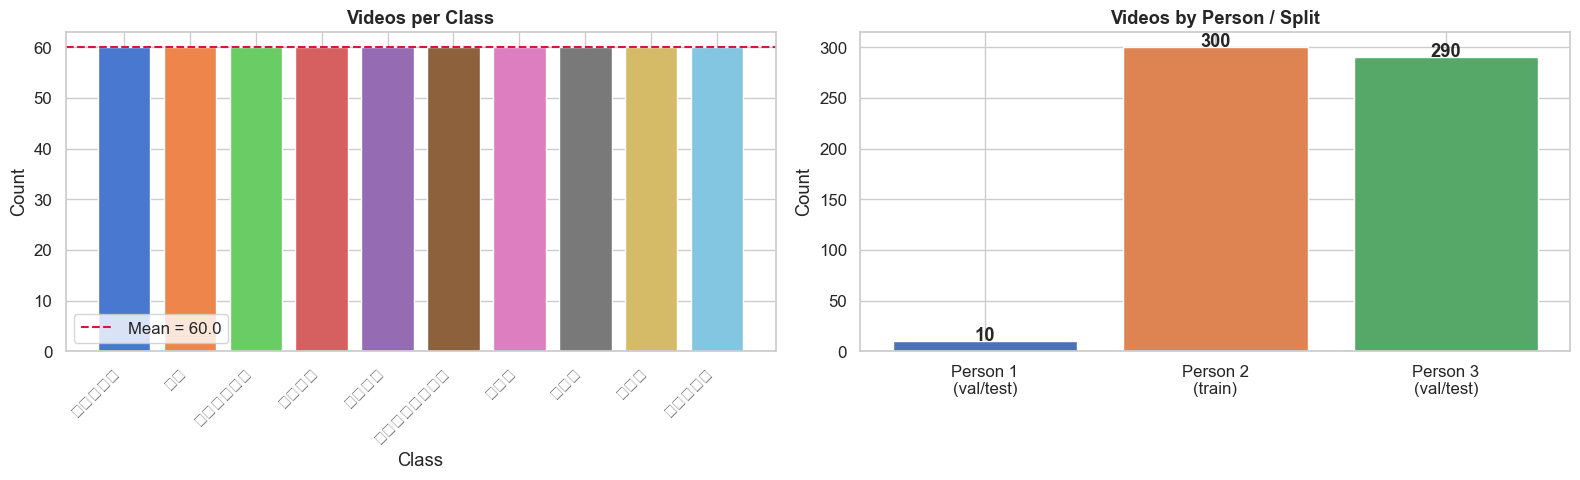


All classes: ['ขอโทษ', 'ดี', 'สวัสดี', 'อะไร', 'เงิน', 'โทรศัพท์', 'ใคร', 'ใช่', 'ไม่', 'ไม่ดี']


In [ ]:
df_all = collect_all_videos(RAW_DIR)

classes      = sorted(df_all['class'].unique())
n_classes    = len(classes)
n_total      = len(df_all)

counts_by_class  = df_all.groupby('class').size().sort_values(ascending=False)
counts_by_person = df_all.groupby('person').size()

print('═' * 50)
print(f'  Classes          : {n_classes}')
print(f'  Total videos     : {n_total}')
print(f'  Videos per class : {counts_by_class.min()} – {counts_by_class.max()}')
print('─' * 50)
print('  Distribution by person:')
person_labels = {1: 'Person 1 (val/test)', 2: 'Person 2 (train)', 3: 'Person 3 (val/test)', -1: 'Unknown'}
for pid, cnt in counts_by_person.items():
    print(f'    Person {pid} → {cnt:3d} videos  ({person_labels.get(pid, "?")})')
print('═' * 50)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.bar(counts_by_class.index, counts_by_class.values, color=sns.color_palette('muted', n_classes))
ax.axhline(counts_by_class.mean(), color='crimson', linestyle='--', label=f'Mean = {counts_by_class.mean():.1f}')
ax.set_title('Videos per Class', fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(counts_by_class.index, rotation=45, ha='right')
ax.legend()

ax = axes[1]
person_cnts = [counts_by_person.get(p, 0) for p in [1, 2, 3]]
person_lbls = ['Person 1\n(val/test)', 'Person 2\n(train)', 'Person 3\n(val/test)']
ax.bar(person_lbls, person_cnts, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('Videos by Person / Split', fontweight='bold')
ax.set_ylabel('Count')
for bar, v in zip(ax.patches, person_cnts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(LOGS_DIR / 'sec1_dataset_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll classes:', classes)

---
## Section 2 — Sample Visualization

Displays 4 uniformly sampled frames from `word.mp4`, `word_02.mp4`, and `word_31.mp4` for every class.

In [ ]:
SAMPLE_VIDEOS = [
    ('',    'P1 (val)'),
    ('_02', 'P2 first'),
    ('_31', 'P2 last'),
]
N_FRAME_PREVIEWS = 4

for cls in classes:
    fig, axes = plt.subplots(
        len(SAMPLE_VIDEOS), N_FRAME_PREVIEWS,
        figsize=(N_FRAME_PREVIEWS * 3, len(SAMPLE_VIDEOS) * 3)
    )
    fig.suptitle(f'Class: {cls}', fontsize=14, fontweight='bold', y=1.01)

    for row_i, (suffix, label) in enumerate(SAMPLE_VIDEOS):
        vid_path = RAW_DIR / f'{cls}{suffix}.mp4'
        row_axes = axes[row_i] if len(SAMPLE_VIDEOS) > 1 else axes

        if not vid_path.exists():
            for ax in row_axes:
                ax.text(0.5, 0.5, 'Missing', ha='center', va='center')
                ax.axis('off')
            row_axes[0].set_ylabel(label, rotation=0, labelpad=60, fontsize=9)
            continue

        frames = sample_frames(vid_path, n_samples=N_FRAME_PREVIEWS)
        for col_i, ax in enumerate(row_axes):
            if col_i < len(frames):
                ax.imshow(frames[col_i])
                ax.set_title(f'Frame {col_i + 1}', fontsize=8)
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            ax.axis('off')
        row_axes[0].set_ylabel(label, rotation=0, labelpad=60, fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(LOGS_DIR / f'sec2_sample_{cls}.png', dpi=100, bbox_inches='tight')
    plt.show()

---
## Section 3 — Video Metadata Analysis

In [4]:
meta_records = []
for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc='Reading metadata'):
    m = get_video_meta(row['path'])
    m.update({'path': row['path'], 'class': row['class'], 'person': row['person'], 'index': row['index']})
    meta_records.append(m)

df_meta = pd.DataFrame(meta_records)
df_meta = df_meta[df_meta['readable']].copy()

print(f'Readable videos : {len(df_meta)} / {len(df_all)}')
print()
print(df_meta[['class', 'person', 'width', 'height', 'fps', 'n_frames', 'duration_s', 'file_size_kb']]
      .describe().round(2).to_string())

Reading metadata:   0%|          | 0/600 [00:00<?, ?it/s]

Readable videos : 600 / 600

       person    width   height     fps  n_frames  duration_s  file_size_kb
count  600.00   600.00   600.00  600.00    600.00      600.00        600.00
mean     2.47  1233.32  1092.01   45.15    128.72        2.71       2687.17
std      0.53   697.45   476.32   14.97     66.04        0.73       4833.84
min      1.00   540.00   600.00   26.54     42.00        1.28        154.41
25%      2.00   540.00   960.00   30.01     65.75        2.16        519.97
50%      2.00   600.00   992.00   51.38    131.00        2.60       1375.66
75%      3.00  1920.00  1080.00   60.00    185.00        3.15       3387.82
max      3.00  2160.00  3840.00   60.00    296.00        6.20      36600.17


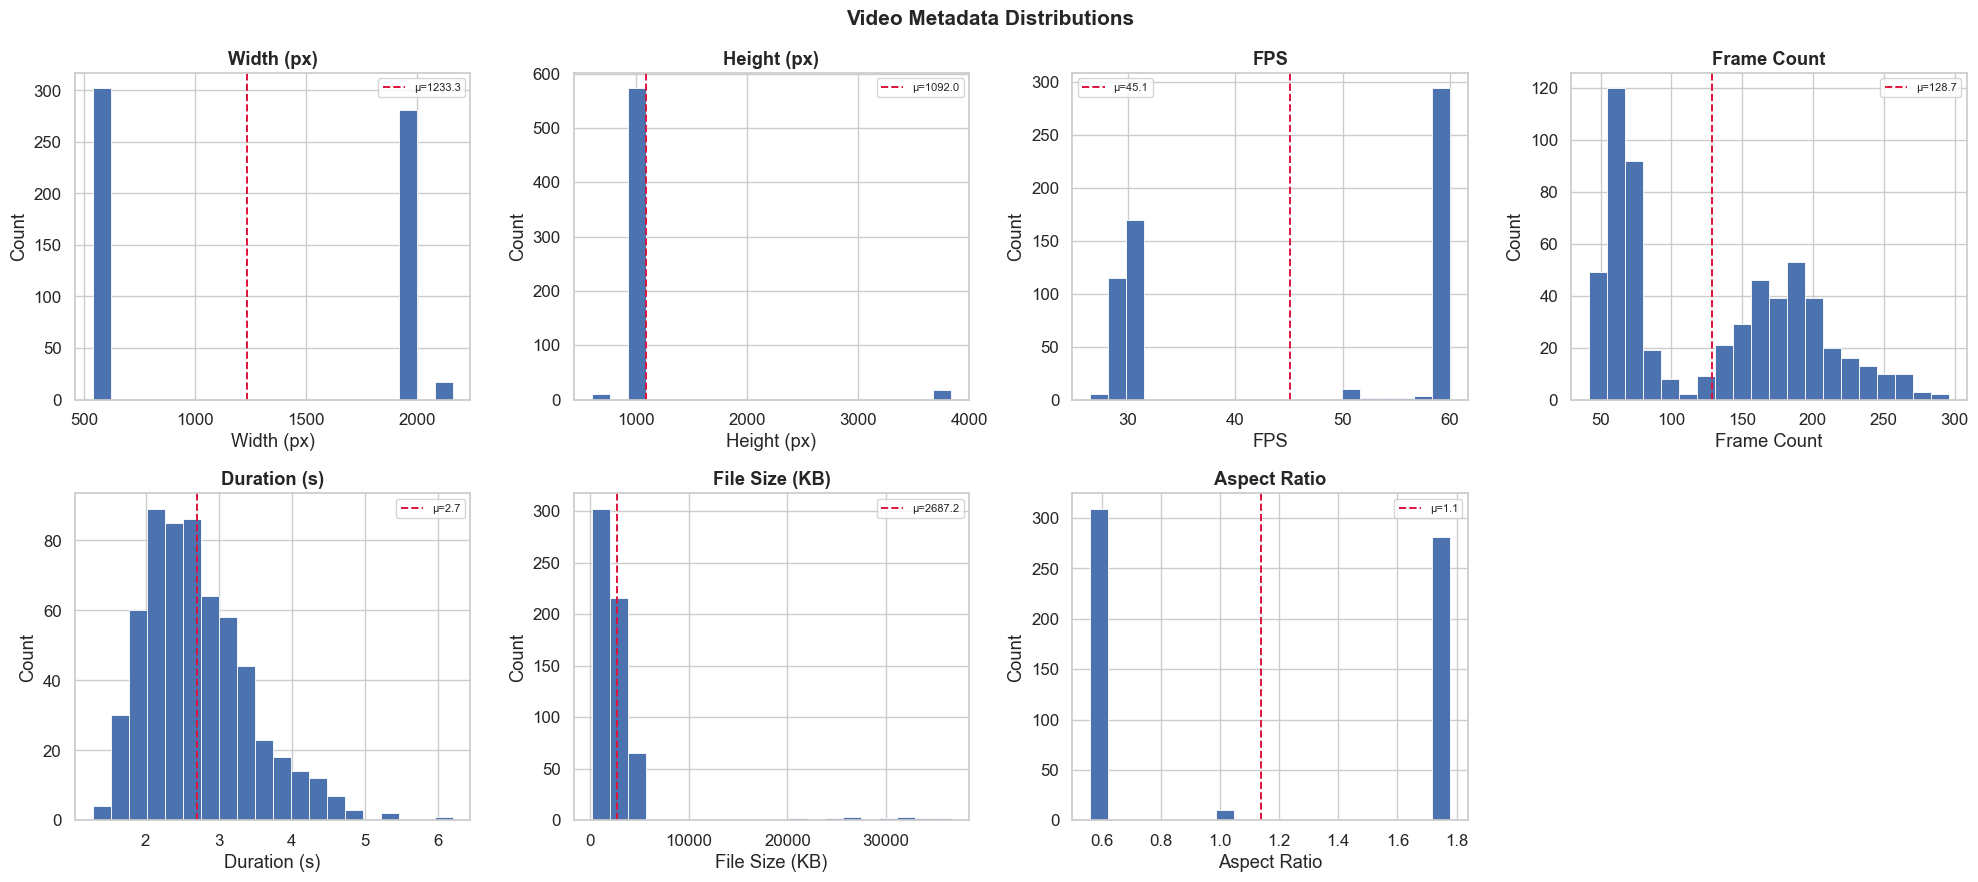


Resolution breakdown:
resolution  count
   540×960    290
  576×1024      2
   600×600     10
 1920×1080    281
 2160×3840     17


In [ ]:
meta_cols = [
    ('width',        'Width (px)'),
    ('height',       'Height (px)'),
    ('fps',          'FPS'),
    ('n_frames',     'Frame Count'),
    ('duration_s',   'Duration (s)'),
    ('file_size_kb', 'File Size (KB)'),
    ('aspect_ratio', 'Aspect Ratio'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes_flat = axes.flatten()
fig.suptitle('Video Metadata Distributions', fontsize=15, fontweight='bold')

for i, (col, title) in enumerate(meta_cols):
    ax = axes_flat[i]
    data = df_meta[col].dropna()
    ax.hist(data, bins=20, color='#4C72B0', edgecolor='white', linewidth=0.6)
    ax.axvline(data.mean(), color='crimson', linestyle='--', linewidth=1.4, label=f'μ={data.mean():.1f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

axes_flat[-1].axis('off')
plt.tight_layout()
plt.savefig(LOGS_DIR / 'sec3_metadata_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

res_counts = df_meta.groupby(['width', 'height']).size().reset_index(name='count')
res_counts['resolution'] = res_counts['width'].astype(str) + '×' + res_counts['height'].astype(str)
print('\nResolution breakdown:')
print(res_counts[['resolution', 'count']].to_string(index=False))

---
## Section 4 — Dataset Consistency Checks

In [ ]:
issues = []

missing = []
for cls in classes:
    p = RAW_DIR / f'{cls}.mp4'
    if not p.exists():
        missing.append(str(p.name))
    for idx in range(P2_START, P2_END + 1):
        p = RAW_DIR / f'{cls}_{idx:02d}.mp4'
        if not p.exists():
            missing.append(str(p.name))
    for idx in range(P3_START, P3_END + 1):
        p = RAW_DIR / f'{cls}_{idx:02d}.mp4'
        if not p.exists():
            missing.append(str(p.name))

print(f'[Missing files]    {len(missing)} missing')
if missing:
    for m in missing[:20]:
        print(f'  ✗ {m}')
    if len(missing) > 20:
        print(f'  … and {len(missing) - 20} more')
    issues.append(f'{len(missing)} missing files')
else:
    print('  ✓ All expected files present')

all_path_strs = set(str(r['path']) for _, r in df_all.iterrows())
if 'path' in df_meta.columns:
    meta_path_strs = set(str(p) for p in df_meta['path'])
else:
    meta_path_strs = set(str(df_all.loc[i, 'path']) for i in df_meta.index if i in df_all.index)

unreadable_paths = all_path_strs - meta_path_strs
print(f'\n[Corrupted/unreadable]  {len(unreadable_paths)} videos')
if unreadable_paths:
    for p in list(unreadable_paths)[:10]:
        print(f'  ✗ {Path(p).name}')
    issues.append(f'{len(unreadable_paths)} unreadable videos')
else:
    print('  ✓ All videos are readable')

print('\n[Duplicate check] Computing MD5 hashes …')
hash_map: dict[str, list[Path]] = {}
for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc='MD5'):
    h = file_md5(row['path'])
    hash_map.setdefault(h, []).append(row['path'])

duplicates = {h: paths for h, paths in hash_map.items() if len(paths) > 1}
print(f'  Duplicate groups : {len(duplicates)}')
for h, paths in duplicates.items():
    print(f'  Hash {h[:8]}… → {[p.name for p in paths]}')
    issues.append(f'Duplicate: {[p.name for p in paths]}')
if not duplicates:
    print('  ✓ No duplicate files')

all_files = list(RAW_DIR.glob('*.mp4'))
valid_pattern = re.compile(r'^.+(_\d{2,})?$')
unexpected = [f for f in all_files if not valid_pattern.match(f.stem)]
print(f'\n[Unexpected filenames]  {len(unexpected)}')
for f in unexpected:
    print(f'  ! {f.name}')
    issues.append(f'Unexpected filename: {f.name}')
if not unexpected:
    print('  ✓ All filenames match expected pattern')

print('\n' + '═' * 50)
if issues:
    print(f'  Total issues found: {len(issues)}')
    for iss in issues:
        print(f'    • {iss}')
else:
    print('  ✓ Dataset is consistent — no issues found.')
print('═' * 50)

[Missing files]    0 missing
  ✓ All expected files present

[Corrupted/unreadable]  0 videos
  ✓ All videos are readable

[Duplicate check] Computing MD5 hashes …


MD5:   0%|          | 0/600 [00:00<?, ?it/s]

  Duplicate groups : 0
  ✓ No duplicate files

[Unexpected filenames]  0
  ✓ All filenames match expected pattern

══════════════════════════════════════════════════
  ✓ Dataset is consistent — no issues found.
══════════════════════════════════════════════════


---
## Section 5 — Frame Length Analysis

Frame count statistics (all videos):
  Min    : 42
  P10    : 57
  Median : 131
  Mean   : 128.7
  P90    : 217
  Max    : 296

  ➜  Recommended fixed sequence length : 224 frames
     (P90 = 217, rounded up to multiple of 8)


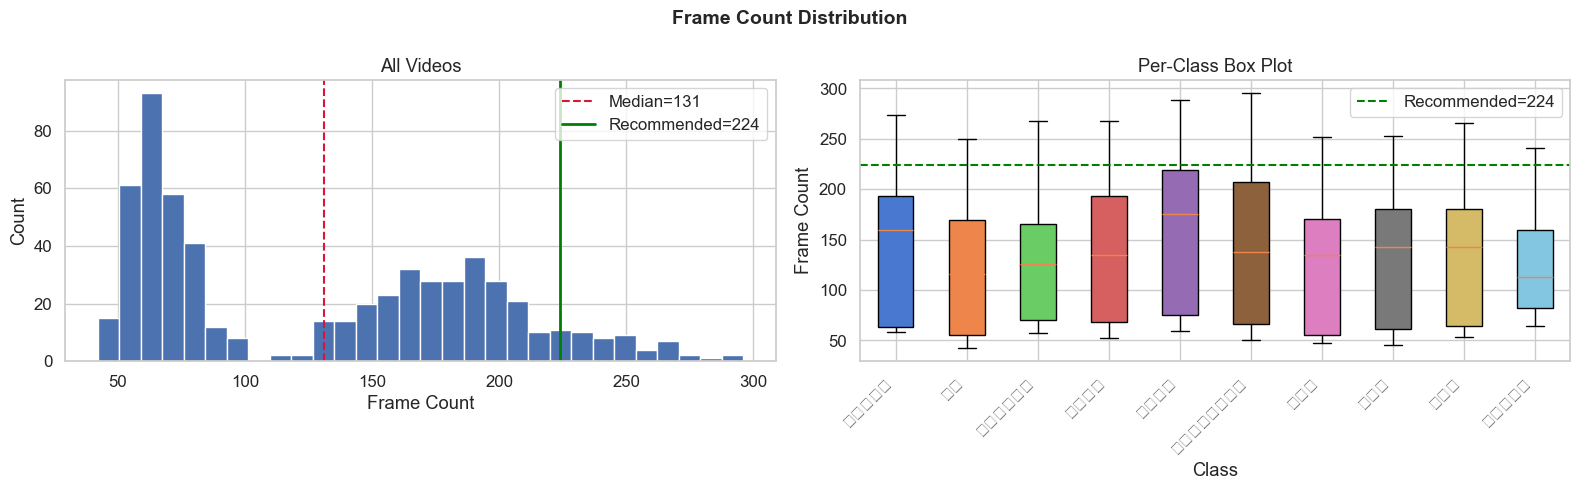

In [ ]:
frame_data = df_meta[['class', 'person', 'n_frames']].copy()

n_min    = int(frame_data['n_frames'].min())
n_max    = int(frame_data['n_frames'].max())
n_mean   = float(frame_data['n_frames'].mean())
n_median = float(frame_data['n_frames'].median())
n_p90    = float(frame_data['n_frames'].quantile(0.90))
n_p10    = float(frame_data['n_frames'].quantile(0.10))

print('Frame count statistics (all videos):')
print(f'  Min    : {n_min}')
print(f'  P10    : {n_p10:.0f}')
print(f'  Median : {n_median:.0f}')
print(f'  Mean   : {n_mean:.1f}')
print(f'  P90    : {n_p90:.0f}')
print(f'  Max    : {n_max}')

recommended = int(np.ceil(n_p90 / 8) * 8)
print(f'\n  ➜  Recommended fixed sequence length : {recommended} frames')
print(f'     (P90 = {n_p90:.0f}, rounded up to multiple of 8)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Frame Count Distribution', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(frame_data['n_frames'], bins=30, color='#4C72B0', edgecolor='white')
ax.axvline(n_median, color='crimson', linestyle='--', label=f'Median={n_median:.0f}')
ax.axvline(recommended, color='green', linestyle='-', linewidth=2, label=f'Recommended={recommended}')
ax.set_xlabel('Frame Count')
ax.set_ylabel('Count')
ax.set_title('All Videos')
ax.legend()

ax = axes[1]
order = sorted(frame_data['class'].unique())
data_by_class = [frame_data[frame_data['class'] == c]['n_frames'].values for c in order]
bp = ax.boxplot(data_by_class, labels=order, patch_artist=True)
palette = sns.color_palette('muted', len(order))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
ax.axhline(recommended, color='green', linestyle='--', linewidth=1.5, label=f'Recommended={recommended}')
ax.set_xlabel('Class')
ax.set_ylabel('Frame Count')
ax.set_title('Per-Class Box Plot')
ax.set_xticklabels(order, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig(LOGS_DIR / 'sec5_frame_length.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 — Human Position Analysis

Estimates the subject bounding box on the middle frame of each video to assess centering and scale consistency.

In [8]:
bbox_records = []
for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc='BBox estimation'):
    path = row['path'] if isinstance(row['path'], Path) else Path(row['path'])
    cap  = cv2.VideoCapture(str(path))
    n    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, float(n // 2))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        continue
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    bbox = estimate_person_bbox(frame_rgb)
    bbox.update({'class': row['class'], 'person': row['person']})
    bbox_records.append(bbox)

df_bbox = pd.DataFrame(bbox_records)
print(df_bbox[['cx', 'cy', 'bw', 'bh']].describe().round(3))

BBox estimation:   0%|          | 0/600 [00:00<?, ?it/s]

            cx       cy       bw       bh
count  600.000  600.000  600.000  600.000
mean     0.500    0.500    1.000    0.999
std      0.004    0.003    0.007    0.006
min      0.413    0.500    0.827    0.910
25%      0.500    0.500    1.000    1.000
50%      0.500    0.500    1.000    1.000
75%      0.500    0.500    1.000    1.000
max      0.500    0.545    1.000    1.000


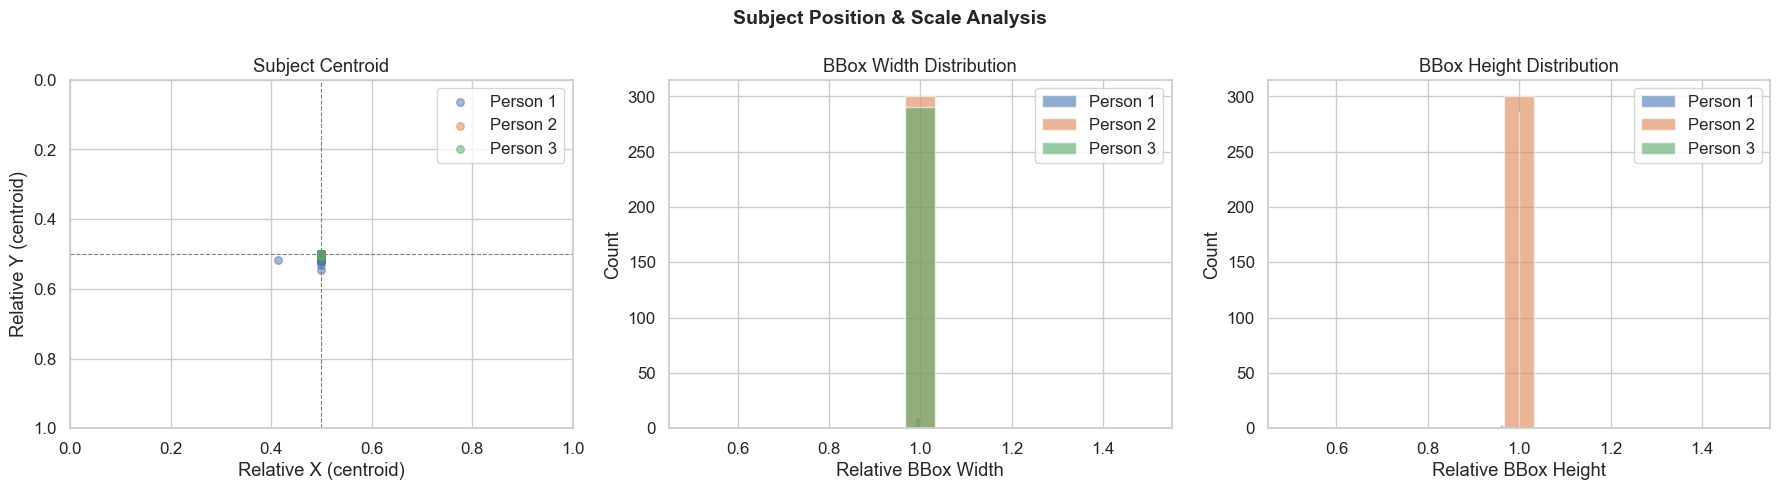


Off-center videos (centroid shift > 0.25): 0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Subject Position & Scale Analysis', fontsize=14, fontweight='bold')

ax = axes[0]
colors = {1: '#4C72B0', 2: '#DD8452', 3: '#55A868'}
for pid in [1, 2, 3]:
    sub = df_bbox[df_bbox['person'] == pid]
    ax.scatter(sub['cx'], sub['cy'], alpha=0.5, s=30,
               c=colors[pid], label=f'Person {pid}')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlim(0, 1); ax.set_ylim(1, 0)  # image coords: y=0 at top
ax.set_xlabel('Relative X (centroid)')
ax.set_ylabel('Relative Y (centroid)')
ax.set_title('Subject Centroid')
ax.legend()

ax = axes[1]
for pid in [1, 2, 3]:
    sub = df_bbox[df_bbox['person'] == pid]['bw']
    ax.hist(sub, bins=15, alpha=0.6, color=colors[pid], label=f'Person {pid}')
ax.set_xlabel('Relative BBox Width')
ax.set_ylabel('Count')
ax.set_title('BBox Width Distribution')
ax.legend()

ax = axes[2]
for pid in [1, 2, 3]:
    sub = df_bbox[df_bbox['person'] == pid]['bh']
    ax.hist(sub, bins=15, alpha=0.6, color=colors[pid], label=f'Person {pid}')
ax.set_xlabel('Relative BBox Height')
ax.set_ylabel('Count')
ax.set_title('BBox Height Distribution')
ax.legend()

plt.tight_layout()
plt.savefig(LOGS_DIR / 'sec6_human_position.png', dpi=150, bbox_inches='tight')
plt.show()

center_tol = 0.25
off_center = df_bbox[
    (abs(df_bbox['cx'] - 0.5) > center_tol) |
    (abs(df_bbox['cy'] - 0.5) > center_tol)
]
print(f'\nOff-center videos (centroid shift > {center_tol}): {len(off_center)}')
if not off_center.empty:
    print(off_center[['class', 'person', 'cx', 'cy']].to_string(index=False))

---
## Section 7 — Lighting & Quality Analysis

In [ ]:
quality_records = []
for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc='Quality analysis'):
    path   = row['path'] if isinstance(row['path'], Path) else Path(row['path'])
    frames = sample_frames(path, n_samples=8)
    if not frames:
        continue
    bc = analyze_brightness_contrast(frames)
    mid_frame = frames[len(frames) // 2]
    blur_score = estimate_blur(mid_frame)
    rec = {'class': row['class'], 'person': row['person'],
           'path': str(path), **bc, 'blur_score': blur_score}
    quality_records.append(rec)

df_quality = pd.DataFrame(quality_records)
print(df_quality[['brightness', 'contrast', 'blur_score']].describe().round(2))

Quality analysis:   0%|          | 0/600 [00:00<?, ?it/s]

       brightness  contrast  blur_score
count      600.00    600.00      600.00
mean        81.61     57.76      152.35
std         39.73      9.08       53.01
min         36.23     40.11        6.24
25%         39.96     49.28      120.16
50%        103.74     52.87      145.90
75%        118.48     66.78      178.38
max        157.66     78.19      455.47


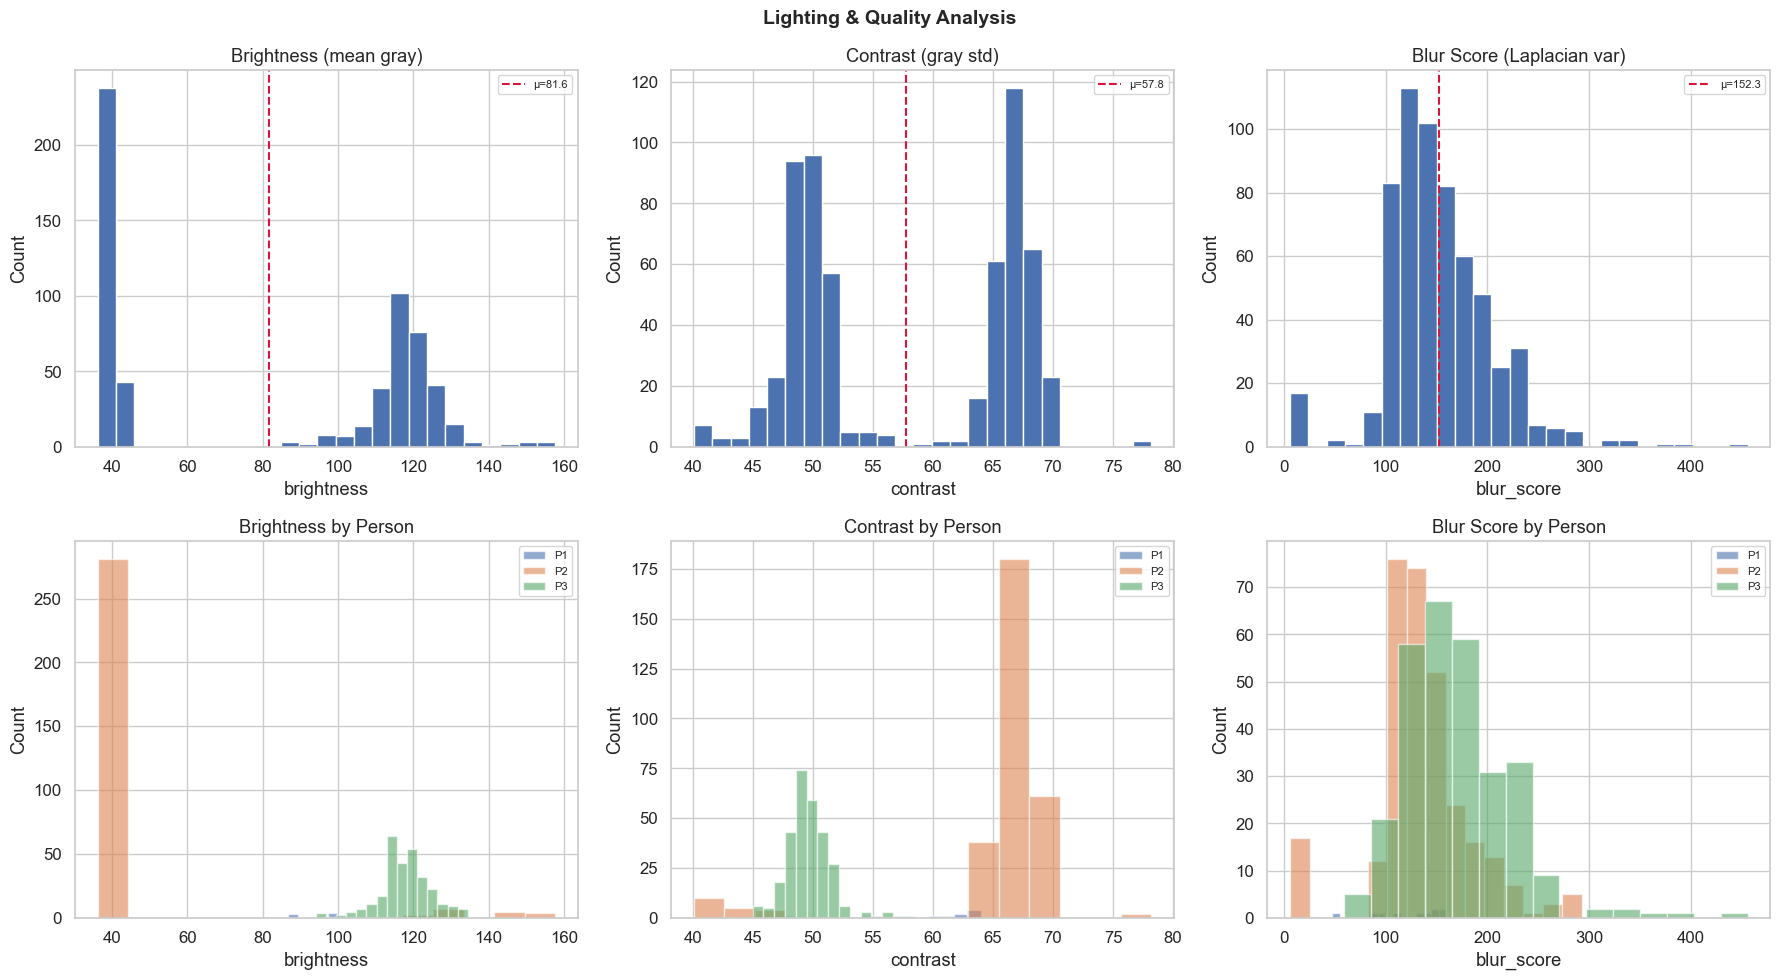

Dim videos (brightness < 39.2): 58
Overexposed (brightness > 124.5): 60
Potentially blurry (blur_score < 107.4): 60


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Lighting & Quality Analysis', fontsize=14, fontweight='bold')

colors = {1: '#4C72B0', 2: '#DD8452', 3: '#55A868'}

for i, (col, title) in enumerate([('brightness', 'Brightness (mean gray)'),
                                    ('contrast',   'Contrast (gray std)'),
                                    ('blur_score', 'Blur Score (Laplacian var)')]):
    ax = axes[0, i]
    ax.hist(df_quality[col].dropna(), bins=25, color='#4C72B0', edgecolor='white')
    mu = df_quality[col].mean()
    ax.axvline(mu, color='crimson', linestyle='--', label=f'μ={mu:.1f}')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

for i, (col, title) in enumerate([('brightness', 'Brightness by Person'),
                                    ('contrast',   'Contrast by Person'),
                                    ('blur_score', 'Blur Score by Person')]):
    ax = axes[1, i]
    for pid in [1, 2, 3]:
        sub = df_quality[df_quality['person'] == pid][col].dropna()
        ax.hist(sub, bins=15, alpha=0.6, color=colors[pid], label=f'P{pid}')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(LOGS_DIR / 'sec7_quality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

dim_thresh   = df_quality['brightness'].quantile(0.10)
bright_thresh= df_quality['brightness'].quantile(0.90)
low_blur_thresh = df_quality['blur_score'].quantile(0.10)

print(f'Dim videos (brightness < {dim_thresh:.1f}):',
      len(df_quality[df_quality['brightness'] < dim_thresh]))
print(f'Overexposed (brightness > {bright_thresh:.1f}):',
      len(df_quality[df_quality['brightness'] > bright_thresh]))
print(f'Potentially blurry (blur_score < {low_blur_thresh:.1f}):',
      len(df_quality[df_quality['blur_score'] < low_blur_thresh]))

---
## Section 8 — Motion Statistics

In [12]:
motion_records = []
for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc='Motion analysis'):
    path   = row['path'] if isinstance(row['path'], Path) else Path(row['path'])
    frames = sample_frames(path, n_samples=12)
    if not frames:
        continue
    m = estimate_motion(frames)
    m.update({'class': row['class'], 'person': row['person'], 'path': str(path)})
    motion_records.append(m)

df_motion = pd.DataFrame(motion_records)
print(df_motion[['motion_mean', 'motion_std', 'static_ratio']].describe().round(4))

Motion analysis:   0%|          | 0/600 [00:00<?, ?it/s]

       motion_mean  motion_std  static_ratio
count     600.0000    600.0000      600.0000
mean        6.9082      2.6937        0.0109
std         3.9950      1.6757        0.0466
min         1.8273      0.3049        0.0000
25%         3.2230      1.2698        0.0000
50%         6.4078      2.3060        0.0000
75%        10.1690      3.7848        0.0000
max        18.0745      9.2662        0.3636


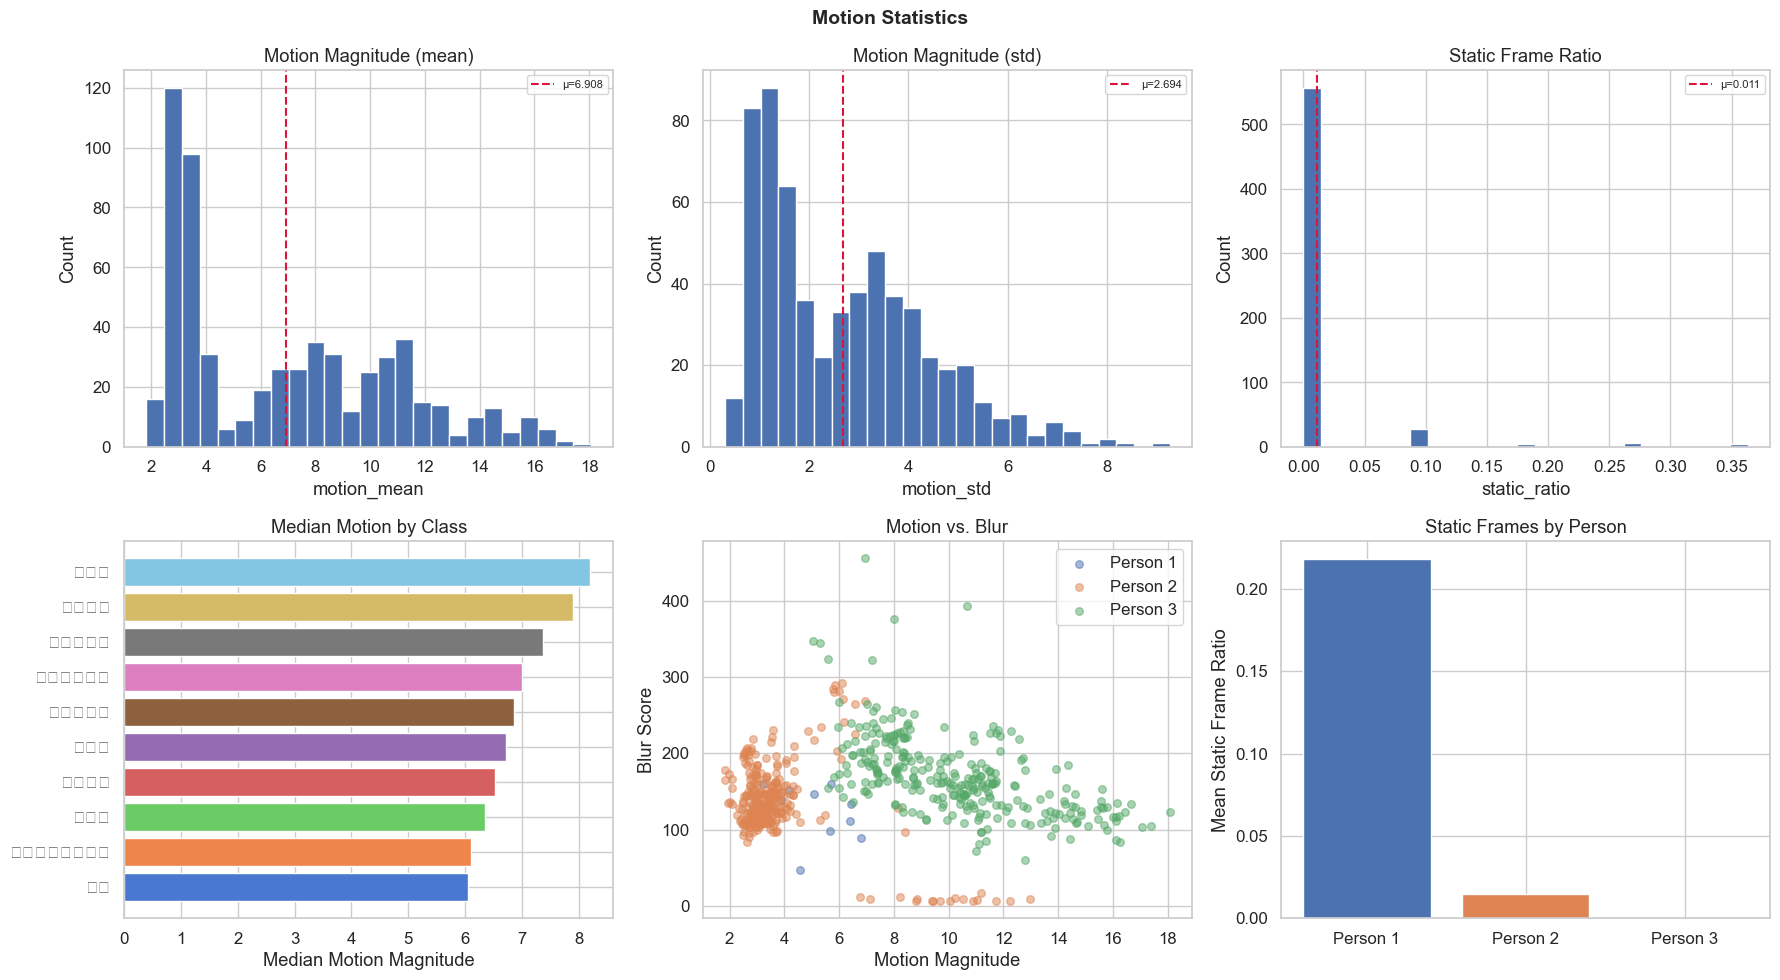

Near-static videos (static_ratio > 0.5): 0


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Motion Statistics', fontsize=14, fontweight='bold')

colors = {1: '#4C72B0', 2: '#DD8452', 3: '#55A868'}
motion_cols = [
    ('motion_mean',  'Motion Magnitude (mean)'),
    ('motion_std',   'Motion Magnitude (std)'),
    ('static_ratio', 'Static Frame Ratio'),
]

for i, (col, title) in enumerate(motion_cols):
    ax = axes[0, i]
    ax.hist(df_motion[col].dropna(), bins=25, color='#4C72B0', edgecolor='white')
    mu = df_motion[col].mean()
    ax.axvline(mu, color='crimson', linestyle='--', label=f'μ={mu:.3f}')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

ax = axes[1, 0]
per_class_motion = df_motion.groupby('class')['motion_mean'].median().sort_values()
ax.barh(per_class_motion.index, per_class_motion.values, color=sns.color_palette('muted', len(per_class_motion)))
ax.set_xlabel('Median Motion Magnitude')
ax.set_title('Median Motion by Class')

ax = axes[1, 1]
merged = df_motion.merge(df_quality[['path', 'blur_score']], on='path', how='left')
for pid in [1, 2, 3]:
    sub = merged[merged['person'] == pid]
    ax.scatter(sub['motion_mean'], sub['blur_score'], alpha=0.5, s=30,
               c=colors[pid], label=f'Person {pid}')
ax.set_xlabel('Motion Magnitude')
ax.set_ylabel('Blur Score')
ax.set_title('Motion vs. Blur')
ax.legend()

ax = axes[1, 2]
per_person_static = df_motion.groupby('person')['static_ratio'].mean()
bar_colors = [colors.get(p, 'gray') for p in per_person_static.index]
ax.bar([f'Person {p}' for p in per_person_static.index],
       per_person_static.values, color=bar_colors)
ax.set_ylabel('Mean Static Frame Ratio')
ax.set_title('Static Frames by Person')

plt.tight_layout()
plt.savefig(LOGS_DIR / 'sec8_motion_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

static_threshold = 0.5
near_static = df_motion[df_motion['static_ratio'] > static_threshold]
print(f'Near-static videos (static_ratio > {static_threshold}): {len(near_static)}')
if not near_static.empty:
    print(near_static[['class', 'person', 'motion_mean', 'static_ratio']].to_string(index=False))

---
## Section 9 — Future Debugging Utilities

Generates outlier reports saved to `../logs/` for use in later debugging sessions.

In [ ]:
df_full = df_meta.copy()
df_full['path_str'] = df_full['path'].astype(str)

df_quality2 = df_quality.copy()
df_quality2['path_str'] = df_quality2['path'].astype(str)

df_motion2 = df_motion.copy()
df_motion2['path_str'] = df_motion2['path'].astype(str)

df_bbox2 = df_bbox.copy()

df_full = df_full.merge(
    df_quality2[['path_str', 'brightness', 'contrast', 'blur_score']],
    on='path_str', how='left'
).merge(
    df_motion2[['path_str', 'motion_mean', 'motion_std', 'static_ratio']],
    on='path_str', how='left'
)

SHORT_THRESH  = df_full['n_frames'].quantile(0.05)
LONG_THRESH   = df_full['n_frames'].quantile(0.95)

outlier_short  = df_full[df_full['n_frames'] <= SHORT_THRESH].copy()
outlier_long   = df_full[df_full['n_frames'] >= LONG_THRESH].copy()
outlier_blur   = df_full[df_full['blur_score'] <= df_full['blur_score'].quantile(0.05)].copy()
outlier_static = df_full[df_full['static_ratio'] >= 0.5].copy()
outlier_dim    = df_full[df_full['brightness'] <= df_full['brightness'].quantile(0.05)].copy()

mode_w = df_full['width'].mode()[0]
mode_h = df_full['height'].mode()[0]
outlier_res = df_full[(df_full['width'] != mode_w) | (df_full['height'] != mode_h)].copy()

report_cols = ['class', 'person', 'index', 'n_frames', 'duration_s',
               'width', 'height', 'brightness', 'blur_score', 'static_ratio']

def show_outlier_group(name: str, df_subset: pd.DataFrame, cols: list[str]) -> None:
    safe_cols = [c for c in cols if c in df_subset.columns]
    print(f'\n── {name} ({len(df_subset)} videos) ──')
    if df_subset.empty:
        print('  None.')
    else:
        print(df_subset[safe_cols].sort_values('class').to_string(index=False))

show_outlier_group(f'Very short (≤ P5 = {SHORT_THRESH:.0f} frames)', outlier_short, report_cols)
show_outlier_group(f'Very long  (≥ P95 = {LONG_THRESH:.0f} frames)', outlier_long,  report_cols)
show_outlier_group('Potentially blurry (blur_score ≤ P5)', outlier_blur,   report_cols)
show_outlier_group('Near-static (static_ratio ≥ 0.5)',    outlier_static, report_cols)
show_outlier_group('Dim videos (brightness ≤ P5)',        outlier_dim,    report_cols)
show_outlier_group('Non-standard resolution',             outlier_res,    report_cols)


── Very short (≤ P5 = 53 frames) (39 videos) ──
   class  person  index  n_frames  duration_s  width  height  brightness  blur_score  static_ratio
      ดี       3     42        48       1.600    540     960      117.81      206.60           0.0
      ดี       3     60        51       1.733    540     960      116.92      201.23           0.0
      ดี       3     57        49       1.633    540     960      122.72      244.66           0.0
      ดี       3     55        42       1.433    540     960      122.86      201.49           0.0
      ดี       3     53        52       1.733    540     960      121.91      235.94           0.0
      ดี       3     51        50       1.666    540     960      120.57      236.78           0.0
      ดี       3     58        51       1.766    540     960      126.38      162.66           0.0
      ดี       3     49        49       1.633    540     960      117.43      228.60           0.0
      ดี       3     47        53       1.833    540     960

Full metrics saved → ..\logs\eda_full_metrics.csv
Outlier report saved → ..\logs\eda_outlier_report.json


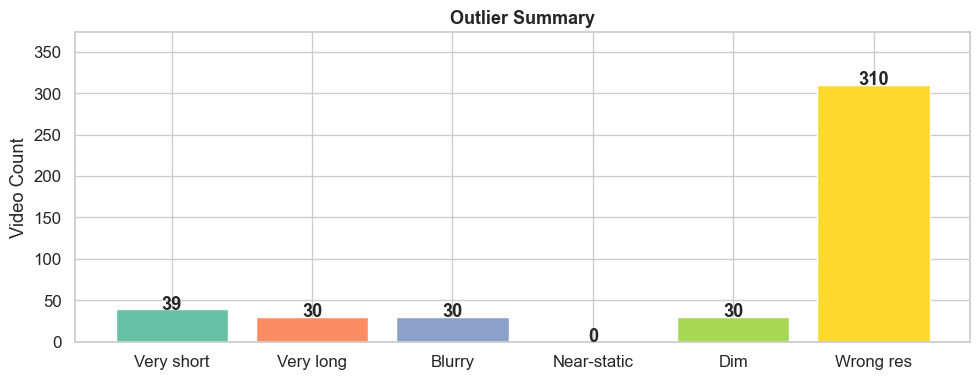


✓ EDA complete. All logs saved to: C:\Users\Napat\termtemsl\experiment_model\logs


In [ ]:
out_csv = LOGS_DIR / 'eda_full_metrics.csv'
df_full.to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f'Full metrics saved → {out_csv}')

def df_to_list(df: pd.DataFrame, cols: list[str]) -> list[dict]:
    safe = [c for c in cols if c in df.columns]
    return df[safe].fillna('').astype(str).to_dict(orient='records')

outlier_report = {
    'generated_at': pd.Timestamp.now().isoformat(),
    'thresholds': {
        'short_frames_p5':  SHORT_THRESH,
        'long_frames_p95':  LONG_THRESH,
        'standard_resolution': f'{mode_w}x{mode_h}',
    },
    'outliers': {
        'very_short':    df_to_list(outlier_short,  report_cols),
        'very_long':     df_to_list(outlier_long,   report_cols),
        'blurry':        df_to_list(outlier_blur,   report_cols),
        'near_static':   df_to_list(outlier_static, report_cols),
        'dim':           df_to_list(outlier_dim,    report_cols),
        'wrong_resolution': df_to_list(outlier_res, report_cols),
    },
}

out_json = LOGS_DIR / 'eda_outlier_report.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(outlier_report, f, ensure_ascii=False, indent=2)
print(f'Outlier report saved → {out_json}')

outlier_counts = {
    'Very short':   len(outlier_short),
    'Very long':    len(outlier_long),
    'Blurry':       len(outlier_blur),
    'Near-static':  len(outlier_static),
    'Dim':          len(outlier_dim),
    'Wrong res':    len(outlier_res),
}

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(outlier_counts.keys(), outlier_counts.values(),
              color=sns.color_palette('Set2', len(outlier_counts)))
for bar, v in zip(bars, outlier_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(v), ha='center', fontweight='bold')
ax.set_title('Outlier Summary', fontsize=13, fontweight='bold')
ax.set_ylabel('Video Count')
ax.set_ylim(0, max(outlier_counts.values()) * 1.2 + 2)
plt.tight_layout()
plt.savefig(LOGS_DIR / 'sec9_outlier_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ EDA complete. All logs saved to:', LOGS_DIR.resolve())